# **IMPORT LIBRARY DAN DATA**

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.2 MB/s eta 0:00:00


In [ ]:
# 1. IMPORT LIBRARY
from google.colab import files
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

uploaded = files.upload()

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
# 2. LOAD DATA
df = pd.read_csv('DatasetMBG .csv')

print("Total Data:", len(df))
print("\nSampel Data Mentah:")
display(df[['created_at', 'full_text']].head())

Saving DatasetMBG .csv to DatasetMBG  (2).csv
Total Data: 3459

Sampel Data Mentah:


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,created_at,full_text
0,Mon Feb 10 15:00:22 +0000 2025,Makan Siang Bergizi Gratis https://t.co/f27aIt...
1,Mon Feb 10 14:55:49 +0000 2025,Momen Prabowo Tanda Tangani Sepatu Siswa di Bo...
2,Mon Feb 10 14:46:41 +0000 2025,@lenteradata Semoga program makan bergizi grat...
3,Mon Feb 10 14:44:56 +0000 2025,Pemprov Babel dan DPRD Bahas Anggaran Program ...
4,Mon Feb 10 14:41:03 +0000 2025,@lenteradata Menurutku berhasil skliki program...


# **INSTALASI SASTRAWI DAN NLTK**

In [ ]:
!pip install Sastrawi
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.8 MB/s eta 0:00:00


# **DATA PREPROCESSING**

# DATA CLEANING DAN CASE FOLDING

In [ ]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.replace('0','o').replace('4','a').replace('1','i')
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    return text

df['clean_text'] = df['full_text'].apply(clean_text)

df = df[df['clean_text'] != '']

print("Sampel Data Setelah Preprocessing:")
display(df[['full_text', 'clean_text']].head(10))

Sampel Data Setelah Preprocessing:


,full_text,clean_text
0,Makan Siang Bergizi Gratis https://t.co/f27aIt...,makan siang bergizi gratis
1,Momen Prabowo Tanda Tangani Sepatu Siswa di Bo...,momen prabowo tanda tangani sepatu siswa di bo...
2,@lenteradata Semoga program makan bergizi grat...,semoga program makan bergizi gratis dri mda te...
3,Pemprov Babel dan DPRD Bahas Anggaran Program ...,pemprov babel dan dprd bahas anggaran program ...
4,@lenteradata Menurutku berhasil skliki program...,menurutku berhasil skliki programnya mda yg ma...
5,#SahabatBahari Kementerian Kelautan dan Perika...,kementerian kelautan dan perikanan kkp tancap ...
6,Adapun peruntukkan penghematan uang kembali Pr...,adapun peruntukkan penghematan uang kembali pr...
7,@prabowo Tolol . Bergizi apaan . Itu program m...,tolol bergizi apaan itu program makan gratis b...
8,Pangdam IV/Diponegoro Mayjen TNI Deddy Suryadi...,pangdam ivdiponegoro mayjen tni deddy suryadi ...
9,MBG : makan bergizi gratis MBG : makan burger ...,mbg makan bergizi gratis mbg makan burger gratis


# TOKENIZATION

In [ ]:
def tokenizing(text):
    return word_tokenize(text)

df['tokens'] = df['clean_text'].apply(tokenizing)

print("Hasil Tokenization:")
display(df[['clean_text', 'tokens']].head(20))

Hasil Tokenization:


,clean_text,tokens
0,makan siang bergizi gratis,"[makan, siang, bergizi, gratis]"
1,momen prabowo tanda tangani sepatu siswa di bo...,"[momen, prabowo, tanda, tangani, sepatu, siswa..."
2,semoga program makan bergizi gratis dri mda te...,"[semoga, program, makan, bergizi, gratis, dri,..."
3,pemprov babel dan dprd bahas anggaran program ...,"[pemprov, babel, dan, dprd, bahas, anggaran, p..."
4,menurutku berhasil skliki programnya mda yg ma...,"[menurutku, berhasil, skliki, programnya, mda,..."
5,kementerian kelautan dan perikanan kkp tancap ...,"[kementerian, kelautan, dan, perikanan, kkp, t..."
6,adapun peruntukkan penghematan uang kembali pr...,"[adapun, peruntukkan, penghematan, uang, kemba..."
7,tolol bergizi apaan itu program makan gratis b...,"[tolol, bergizi, apaan, itu, program, makan, g..."
8,pangdam ivdiponegoro mayjen tni deddy suryadi ...,"[pangdam, ivdiponegoro, mayjen, tni, deddy, su..."
9,mbg makan bergizi gratis mbg makan burger gratis,"[mbg, makan, bergizi, gratis, mbg, makan, burg..."


# STOPWORD REMOVAL

In [ ]:

from nltk.corpus import stopwords

list_stopwords = set(stopwords.words('indonesian'))

stopword_tambahan = stopword_tambahan = stopwords_custom = stopwords_custom = {

    # Topik utama
    'makan', 'gratis', 'bergizi', 'program', 'mbg', 'siang', 'gizi',
    'prabowo', 'gibran', 'presiden', 'subianto', 'pemerintah', 'ri', 'pak',
    'jokowi', 'wapres', 'wakil', 'menteri',

    # non-sentimen
    'pangan', 'jenderal', 'sekolah', 'anggaran', 'indonesia',
    'kesehatan', 'masyarakat', 'polri', 'langkah', 'ketahanan',
    'tni', 'pendidikan', 'purn', 'nasional',
    'kapolri', 'swasembada', 'asta', 'cita', 'polisi',
    'drs', 'sigit', 'listyo', 'menginisiasi',
    'makanan', 'sdn', 'negara', 'meninjau',
    'prabowogibran', 'dana', 'siswa', 'generasi',
    'jakarta', 'ikn', 'senin',
    'kementerian', 'kabinet', 'pejabat', 'apbn',

    # konteks netral
    'pelaksanaan', 'bertujuan',
    'digagas', 'pemerintahan', 'prioritas',
    'rekrutmen', 'pertanian', 'pelayanan',
    'bidang', 'peran', 'memiliki',
    'bangsa', 'daerah', 'negeri',
    'berjalan', 'berkelanjutan',
    'kebijakan', 'kampanye', 'tinjau',
     'fokus', 'mengunjungi',

    # Lokasi / waktu / objek netral
    'jawa', 'papua', 'barat', 'timur', 'jaya',
    'bogor', 'kedung', 'pagi', 'dapur', 'menu',
    'sd', 'senin', 'kota', 'rumah', 'lapangan',

    # bahasa informal
    'yg', 'ga', 'gak', 'aja', 'tuh', 'sih', 'nih',
    'utk', 'sdh', 'dgn', 'krn', 'kalo', 'klo',
    'dr', 'jd', 'jgn', 'blm',
    'sy', 'aku', 'gue', 'gw', 'lu',
    'ya', 'nya', 'gas', 'udah', 'amp', 'tp',
    'jg', 'emang', 'si', 'banget', 'langsung',
    'org', 'kaya', 'biar', 'gini', 'dapet',
    'tau', 'pake', 'bilang', 'coba', 'liat',
    'sampe', 'dah', 'karna',

    # Stopword umum Bahasa Indonesia
    'dan', 'yang', 'di', 'untuk', 'ini', 'itu', 'dari', 'dengan',
    'ke', 'dalam', 'ada', 'buat', 'juga', 'tapi',
    'mau', 'sudah', 'akan', 'masih', 'pada',
    'adalah', 'sebagai', 'karena', 'ia', 'kami', 'anda'
}



# Gabungkan ke dalam satu set
list_stopwords.update(stopword_tambahan)

# Fungsi penghapus
def remove_stopwords(tokens):
    return [word for word in tokens if word not in list_stopwords and len(word) > 1]

df['filtered_tokens'] = df['tokens'].apply(remove_stopwords)


display(df[['tokens', 'filtered_tokens']].head(1000))

,tokens,filtered_tokens
0,"[makan, siang, bergizi, gratis]",[]
1,"[momen, prabowo, tanda, tangani, sepatu, siswa...","[momen, tanda, tangani, sepatu]"
2,"[semoga, program, makan, bergizi, gratis, dri,...","[semoga, dri, mda, berlanjut, programnya, sma]"
3,"[pemprov, babel, dan, dprd, bahas, anggaran, p...","[pemprov, babel, dprd, bahas, apbd]"
4,"[menurutku, berhasil, skliki, programnya, mda,...","[menurutku, berhasil, skliki, programnya, mda,..."
...,...,...
996,"[udahlah, pak, pres, mending, dipending, dulu,...","[udahlah, pres, mending, dipending, ginimah, g..."
997,"[menu, siang, hari, ini, mie, aceh, makan, sia...","[mie, aceh, mahal, tahajjud, qobliyah, subuh, ..."
998,"[jokowi, ternyata, amat, pelit, kepada, negara...","[pelit, uang, trilyun, sakunya, bantu, sewa, b..."
999,"[aku, milih, karena, menurut, pandangan, saya,...","[milih, pandangan, anies, alternatif, konserva..."


# STEMMING

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    # Stem setiap kata dalam list
    return [stemmer.stem(word) for word in tokens]

df['stemmed_tokens'] = df['filtered_tokens'].apply(stemming)

print("Hasil Stemming:")
display(df[['filtered_tokens', 'stemmed_tokens']].head())

Hasil Stemming:


,filtered_tokens,stemmed_tokens
0,[],[]
1,"[momen, tanda, tangani, sepatu]","[momen, tanda, tangan, sepatu]"
2,"[semoga, dri, mda, berlanjut, programnya, sma]","[moga, dri, mda, lanjut, program, sma]"
3,"[pemprov, babel, dprd, bahas, apbd]","[pemprov, babel, dprd, bahas, apbd]"
4,"[menurutku, berhasil, skliki, programnya, mda,...","[turut, hasil, skliki, program, mda, bukti, tu..."


# MENGGABUNG HASIL STEMMED

In [ ]:

if 'stemmed_tokens' in df.columns:
    df['final_text'] = df['stemmed_tokens'].apply(lambda x: ' '.join(map(str, x)))
    print("Berhasil! Kolom 'final_text' sudah dibuat.")

    df = df[df['final_text'] != '']

    print("Contoh data siap label:")
    display(df[['stemmed_tokens', 'final_text']].head(10))

else:
    print("Stemmed tokens tidak ditemukan")

Berhasil! Kolom 'final_text' sudah dibuat.
Contoh data siap label:


,stemmed_tokens,final_text
1,"[momen, tanda, tangan, sepatu]",momen tanda tangan sepatu
2,"[moga, dri, mda, lanjut, program, sma]",moga dri mda lanjut program sma
3,"[pemprov, babel, dprd, bahas, apbd]",pemprov babel dprd bahas apbd
4,"[turut, hasil, skliki, program, mda, bukti, tu...",turut hasil skliki program mda bukti turun ang...
5,"[laut, ikan, kkp, tancap, realisasi, revitalis...",laut ikan kkp tancap realisasi revitalisasi ta...
6,"[untuk, hemat, uang, tegas, realisasi, kena, b...",untuk hemat uang tegas realisasi kena bangun
7,"[tolol, syukur]",tolol syukur
8,"[pangdam, ivdiponegoro, mayjen, deddy, suryadi...",pangdam ivdiponegoro mayjen deddy suryadi sema...
9,[burger],burger
10,"[teliti, lpem, ui, awas, ketat, rentan, inefis...",teliti lpem ui awas ketat rentan inefisiensi


# **PELABELAN DATA**



In [ ]:

positif_words = {
    'mendukung', 'dukung', 'sehat', 'mewujudkan', 'penuh', 'memberikan',
    'baik', 'sukses', 'sukseskan', 'penting', 'nyata', 'kualitas', 'strategis',
    'semangat', 'mantap', 'keren', 'hebat', 'setuju', 'sepakat', 'bagus',
    'manfaat', 'terima', 'kasih', 'syukur', 'alhamdulillah', 'aman',
    'optimis', 'maju', 'berhasil', 'bangga', 'senang', 'puas', 'jelas',
    'paham', 'mengerti', 'bantu', 'guna', 'perlu', 'butuh', 'cinta',
    'peduli', 'adil', 'bijak', 'jujur', 'asli', 'sah', 'benar', 'tepat',
    'enak', 'lezat', 'sedap', 'kenyang', 'gizi', 'nutrisi', 'bersih',
    'higienis', 'layak', 'murah', 'hemat', 'cukup', 'lengkap','ceria', 'bahagia', 'senyum', 'riang', 'gembira',
    'happy', 'terbantu', 'terpenuhi', 'anggaran', 'dana', 'biaya',
    'cuma', 'hanya', 'doang', 'janji',
}

negatif_words = {
    'anggaran', 'dana', 'biaya',
    'cuma', 'hanya', 'doang',
    'malah', 'mending',
    'bikin', 'buat',
    'jelek', 'buruk', 'tolak', 'batal', 'gagal', 'benci', 'marah', 'kesal',
    'kecewa', 'sedih', 'takut', 'khawatir', 'ragu', 'bingung', 'pusing',
    'stress', 'beban', 'rugi', 'hancur', 'rusak', 'kacau', 'parah', 'payah',
    'bodoh', 'gila', 'aneh', 'salah', 'bohong', 'palsu', 'hoax', 'tipu',
    'curang', 'jahat', 'ribet', 'sulit', 'susah', 'lambat', 'lelet', 'telat',
    'macet', 'antri', 'kotor', 'jorok', 'bau', 'busuk', 'korupsi', 'maling',
    'pencitraan', 'omong', 'kosong', 'janji', 'utang', 'boros', 'mahal',
    'habis', 'langka', 'masalah', 'kasus', 'skandal', 'ribut', 'gaduh',
    'sakit', 'muntah', 'mual', 'keracunan', 'hambar', 'asin', 'pahit',
    'keras', 'alot', 'mentah', 'dingin', 'sedikit', 'kurang', 'kecil',
}

kata_kasar = {
    'tolol','tll','tlol',
    'bodoh','bdh',
    'goblok','gblk',
    'bangsat','bgsd',
    'kampret','kmprt',
    'bacot','bct',
    'tai','t4i'
}

negatif_words = negatif_words.union(kata_kasar)

def labelling(text):
    score = 0
    words = str(text).split()

    for word in words:
        if word in positif_words:
            score += 1
        elif word in negatif_words:
            score -= 1


    if score > 0:
        return 'Positif'
    elif score < 0:
        return 'Negatif'
    else:
        return 'Netral'

df['sentimen'] = df['final_text'].apply(labelling)

# HAPUS DATA NETRAL
df_biner = df[df['sentimen'] != 'Netral'].copy()

print(f"Total Data: {len(df)}")
print(f"Data Bersih (Positif & Negatif): {len(df_biner)}")
display(df_biner[['final_text', 'sentimen']].tail(1000))

Total Data: 3333
Data Bersih (Positif & Negatif): 1875


/tmp/ipython-input-3970701070.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentimen'] = df['final_text'].apply(labelling)


,final_text,sentimen
1611,ujung warga suruh patungan bpjs cover suruh ny...,Positif
1615,sibuk bersih dosa mulyono pajak pagar laut jeb...,Positif
1616,banding jujur tuju sandang butuh pokok harga d...,Positif
1623,keren sahkan ruu ampas aset uu biaya kuliah pt...,Positif
1624,enak,Positif
...,...,...
3450,ndut drpd mending,Negatif
3453,rb enak ketimbang,Positif
3454,berkat tonggoku sing mari tinggal ae luwih ena...,Positif
3455,tunggu hasil foto lapor kait unggul ketemu moh...,Positif


# **SPLIT DATA**

In [ ]:

from sklearn.model_selection import train_test_split

X = df_biner['final_text']
y = df_biner['sentimen']

# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total Data Siap: {len(df_biner)}")
print(f"Data Latih : {len(X_train)} baris")
print(f"Data Uji: {len(X_test)} baris")

Total Data Siap: 1875
Data Latih : 1500 baris
Data Uji: 375 baris


# **TF-IDF**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Ukuran Matriks Data Latih: {X_train_vec.shape}")

feature_names = vectorizer.get_feature_names_out()

data_pertama = X_train_vec[0].toarray()

index_bukan_nol = np.where(data_pertama > 0)[1]

df_tfidf_sample = pd.DataFrame(data_pertama, columns=feature_names)

print("TF-IDF:")
display(df_tfidf_sample.iloc[:, index_bukan_nol])

Ukuran Matriks Data Latih: (1500, 3330)
TF-IDF:


,alhamdulillah,at,boneka,doa,sapa,siswi,smpit,taufiq
0,0.329538,0.364561,0.364561,0.33875,0.350025,0.350025,0.364561,0.364561


# **TRAINING DENGAN MODEL NAIVE BAYES**

Melatih model
Akurasi Model: 81.07%

Detail Laporan Klasifikasi:
              precision    recall  f1-score   support

     Negatif       1.00      0.30      0.46       101
     Positif       0.79      1.00      0.89       274

    accuracy                           0.81       375
   macro avg       0.90      0.65      0.67       375
weighted avg       0.85      0.81      0.77       375



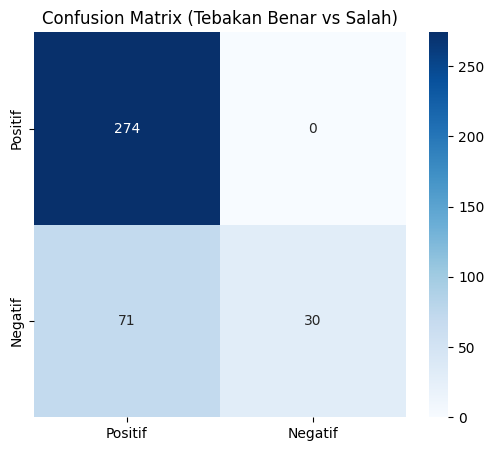

In [ ]:

from sklearn.naive_bayes import MultinomialNB

# algoritma Naive Bayes
nb_model = MultinomialNB()

print("Melatih model")
nb_model.fit(X_train_vec, y_train)


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Uji model dengan Data Uji (X_test)
y_pred = nb_model.predict(X_test_vec)

# 2. Hitung Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {akurasi * 100:.2f}%")

# 3. Laporan Detail
print("\nDetail Laporan Klasifikasi:")
print(classification_report(y_test, y_pred))

# 4. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Positif', 'Negatif'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positif', 'Negatif'],
            yticklabels=['Positif', 'Negatif'])
plt.title('Confusion Matrix (Tebakan Benar vs Salah)')
plt.show()

# **UJI COBA MANUAL**

In [ ]:


def prediksi_sentimen(kalimat_baru):
    vec = vectorizer.transform([kalimat_baru])

    hasil = nb_model.predict(vec)[0]

    return hasil

contoh1 = "menu nya bagus tapi sayangnya rasa dan kualitas nya ga banget "
contoh2 = "Makanannya basi, bikin sakit perut, parah banget anggarannya dikorupsi"
contoh3 = "Biasa aja sih rasanya, tapi lumayan gratis"

print(f"Kalimat: '{contoh1}' -> Sentimen: {prediksi_sentimen(contoh1)}")
print(f"Kalimat: '{contoh2}' -> Sentimen: {prediksi_sentimen(contoh2)}")
print(f"Kalimat: '{contoh3}' -> Sentimen: {prediksi_sentimen(contoh3)}")

Kalimat: 'menu nya bagus tapi sayangnya rasa dan kualitas nya ga banget ' -> Sentimen: Positif
Kalimat: 'Makanannya basi, bikin sakit perut, parah banget anggarannya dikorupsi' -> Sentimen: Negatif
Kalimat: 'Biasa aja sih rasanya, tapi lumayan gratis' -> Sentimen: Positif


# **WORDCLOUD**

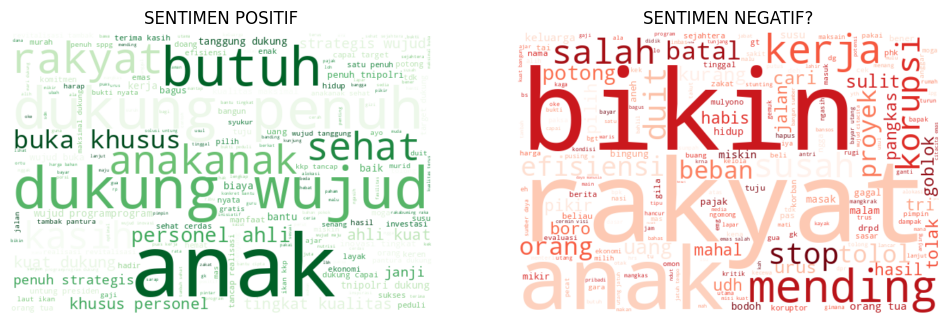

In [ ]:

from wordcloud import WordCloud

df_positif = df_biner[df_biner['sentimen'] == 'Positif']
df_negatif = df_biner[df_biner['sentimen'] == 'Negatif']


text_positif = ' '.join(df_positif['final_text'].astype(str))
text_negatif = ' '.join(df_negatif['final_text'].astype(str))

wc_pos = WordCloud(width=600, height=400, background_color='white', colormap='Greens').generate(text_positif)
wc_neg = WordCloud(width=600, height=400, background_color='white', colormap='Reds').generate(text_negatif)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_pos, interpolation='bilinear')
plt.title('SENTIMEN POSITIF')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_neg, interpolation='bilinear')
plt.title('SENTIMEN NEGATIF?')
plt.axis('off')

plt.show()

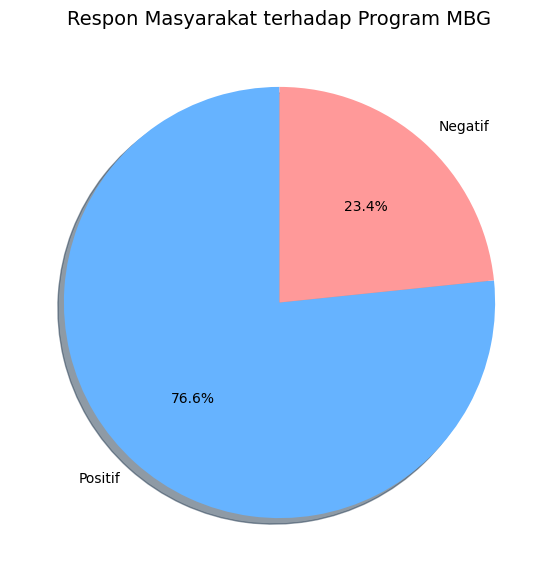

Ringkasan Jumlah Data:
sentimen
Positif    1437
Negatif     438
Name: count, dtype: int64


In [ ]:

counts = df_biner['sentimen'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#66b3ff', '#ff9999']
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors, shadow=True)
plt.title('Respon Masyarakat terhadap Program MBG', fontsize=14)
plt.show()

print("Ringkasan Jumlah Data:")
print(counts)